# Customer Churn Analysis — Complete Python Data Analytics Project



**Portfolio**

This project follows a complete data analyst workflow:

**Import Libraries → Import CSV → Understand Data → Clean Data → Explore Data → Create KPIs → Case Study → Visualization → Business Insights → Recommendations**

### Business Problem
A subscription company wants to understand customer churn and identify the customer groups most likely to leave.

### Main Questions
1. What is the overall churn rate?
2. Which contract type has the highest churn?
3. Which region has the highest churn?
4. Does customer tenure affect churn?
5. Which payment methods are associated with higher churn?
6. Does monthly charge affect churn?
7. Do support tickets and late payments relate to churn?
8. Which customer segments are high-value but at risk?
9. What business actions should management take?

## 1. Import Libraries

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Plot style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Import Data from CSV

In [2]:
# Read the CSV file

df=pd.read_csv(r"C:\Users\DELL\Downloads\customer_churn_data1.csv")
df

,customer_id,gender,age,region,contract_type,internet_service,payment_method,tenure_months,monthly_charges,total_charges,support_tickets,late_payments,senior_citizen,churn,signup_date
0,10001,Male,68,West,Month-to-Month,Fiber Optic,Credit Card,9,117.21,979.66,3.00,1,Yes,No,12-08-2020
1,10002,Female,64,East,Two Year,Fiber Optic,Mailed Check,14,56.13,792.22,0.00,1,Yes,No,26-10-2024
2,10003,Female,64,East,Month-to-Month,Fiber Optic,Credit Card,26,43.55,"1,171.88",4.00,1,Yes,No,23-06-2023
3,10004,Female,21,West,One Year,Fiber Optic,Bank Transfer,62,74.52,"4,340.70",2.00,0,No,No,11-02-2022
4,10005,Male,24,East,One Year,Fiber Optic,Electronic Check,25,89.40,"2,304.69",3.00,1,No,No,27-12-2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2510,11626,Female,19,East,Month-to-Month,DSL,Credit Card,35,93.42,"3,186.91",1.00,0,No,No,08-07-2023
2511,10604,Male,65,West,Two Year,Fiber Optic,Bank Transfer,39,97.04,"3,526.79",3.00,3,Yes,No,22-11-2021
2512,11182,Male,54,East,One Year,No Internet,Electronic Check,69,46.23,"3,094.20",2.00,0,No,No,22-04-2021
2513,11888,Male,73,North,One Year,Fiber Optic,Mailed Check,46,67.48,"3,240.71",3.00,1,Yes,No,28-10-2023


## 3. First Look at the Dataset

In [3]:
# First 5 rows
df.head()

,customer_id,gender,age,region,contract_type,internet_service,payment_method,tenure_months,monthly_charges,total_charges,support_tickets,late_payments,senior_citizen,churn,signup_date
0,10001,Male,68,West,Month-to-Month,Fiber Optic,Credit Card,9,117.21,979.66,3.00,1,Yes,No,12-08-2020
1,10002,Female,64,East,Two Year,Fiber Optic,Mailed Check,14,56.13,792.22,0.00,1,Yes,No,26-10-2024
2,10003,Female,64,East,Month-to-Month,Fiber Optic,Credit Card,26,43.55,"1,171.88",4.00,1,Yes,No,23-06-2023
3,10004,Female,21,West,One Year,Fiber Optic,Bank Transfer,62,74.52,"4,340.70",2.00,0,No,No,11-02-2022
4,10005,Male,24,East,One Year,Fiber Optic,Electronic Check,25,89.40,"2,304.69",3.00,1,No,No,27-12-2024


In [4]:
# Last 5 rows
df.tail()

,customer_id,gender,age,region,contract_type,internet_service,payment_method,tenure_months,monthly_charges,total_charges,support_tickets,late_payments,senior_citizen,churn,signup_date
2510,11626,Female,19,East,Month-to-Month,DSL,Credit Card,35,93.42,"3,186.91",1.00,0,No,No,08-07-2023
2511,10604,Male,65,West,Two Year,Fiber Optic,Bank Transfer,39,97.04,"3,526.79",3.00,3,Yes,No,22-11-2021
2512,11182,Male,54,East,One Year,No Internet,Electronic Check,69,46.23,"3,094.20",2.00,0,No,No,22-04-2021
2513,11888,Male,73,North,One Year,Fiber Optic,Mailed Check,46,67.48,"3,240.71",3.00,1,Yes,No,28-10-2023
2514,12027,Female,59,East,One Year,Fiber Optic,Electronic Check,11,126.01,"1,470.98",4.00,1,No,No,15-01-2025


In [5]:
# Random sample
df.sample(5, random_state=42)


,customer_id,gender,age,region,contract_type,internet_service,payment_method,tenure_months,monthly_charges,total_charges,support_tickets,late_payments,senior_citizen,churn,signup_date
617,10618,Male,71,South,Month-to-Month,No Internet,Electronic Check,46,81.91,"3,700.28",3.00,2,Yes,No,27-05-2021
927,10928,Female,72,South,One Year,No Internet,Credit Card,46,61.83,"3,028.69",3.00,0,Yes,No,19-06-2022
942,10943,Female,34,South,One Year,Fiber Optic,Electronic Check,18,79.93,"1,470.89",2.00,3,No,No,21-02-2020
973,10974,Male,36,North,Month-to-Month,Fiber Optic,Credit Card,66,44.31,"2,894.69",3.00,1,No,No,01-08-2025
1967,11968,Male,66,West,Two Year,Fiber Optic,Electronic Check,14,105.39,"1,577.45",1.00,2,Yes,No,23-04-2025


In [6]:
# Dataset dimensions
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 2515
Number of columns: 15


## 4. Understand the Data Structure

In [9]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2515 entries, 0 to 2514
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       2515 non-null   int64  
 1   gender            2515 non-null   object 
 2   age               2515 non-null   int64  
 3   region            2515 non-null   object 
 4   contract_type     2515 non-null   object 
 5   internet_service  2515 non-null   object 
 6   payment_method    2500 non-null   object 
 7   tenure_months     2515 non-null   int64  
 8   monthly_charges   2500 non-null   float64
 9   total_charges     2515 non-null   float64
 10  support_tickets   2500 non-null   float64
 11  late_payments     2515 non-null   int64  
 12  senior_citizen    2515 non-null   object 
 13  churn             2515 non-null   object 
 14  signup_date       2515 non-null   object 
dtypes: float64(3), int64(4), object(8)
memory usage: 294.9+ KB


In [10]:
# Column names
print(df.columns.tolist())

['customer_id', 'gender', 'age', 'region', 'contract_type', 'internet_service', 'payment_method', 'tenure_months', 'monthly_charges', 'total_charges', 'support_tickets', 'late_payments', 'senior_citizen', 'churn', 'signup_date']


In [11]:
# Statistical summary
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,"2,515.00",NaN,NaN,NaN,"11,250.57",721.82,"10,001.00","10,625.50","11,250.00","11,877.50","12,500.00"
gender,2515,2,Male,1319,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,"2,515.00",NaN,NaN,NaN,46.93,16.81,18.00,33.00,47.00,62.00,75.00
region,2515,5,East,775,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contract_type,2515,4,Month-to-Month,1277,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internet_service,2515,3,Fiber Optic,1218,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_method,2500,5,Electronic Check,835,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure_months,"2,515.00",NaN,NaN,NaN,36.54,20.97,1.00,18.00,36.00,55.00,72.00
monthly_charges,"2,500.00",NaN,NaN,NaN,79.11,25.22,20.00,61.84,78.61,96.50,160.00
total_charges,"2,515.00",NaN,NaN,NaN,"2,888.69","1,966.61",23.84,"1,252.19","2,564.84","4,286.85","10,524.06"


## 5. Data Cleaning 

### 5.1 Check duplicate rows

In [12]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 15


In [13]:
# Remove duplicate rows

df = df.drop_duplicates().reset_index(drop=True)

print("Rows after removing duplicates:", len(df))


Rows after removing duplicates: 2500


### 5.2 Check missing values

In [16]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_report = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent.round(2)
})

missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_report = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent.round(2)
})

missing_report

,missing_count,missing_percent
payment_method,15,0.60
support_tickets,15,0.60
monthly_charges,15,0.60
age,0,0.00
region,0,0.00
gender,0,0.00
customer_id,0,0.00
internet_service,0,0.00
contract_type,0,0.00
tenure_months,0,0.00


### 5.3 Clean text columns

In [17]:
text_columns = [
    "gender",
    "region",
    "contract_type",
    "internet_service",
    "payment_method",
    "senior_citizen",
    "churn"
]

for col in text_columns:
    df[col] = df[col].astype("string").str.strip()

# Standardize inconsistent labels
df["region"] = df["region"].str.title()
df["payment_method"] = df["payment_method"].str.title()
df["contract_type"] = df["contract_type"].replace({
    "Month-To-Month": "Month-to-Month"
})

print("Text columns cleaned.")

Text columns cleaned.


### 5.4 Convert date column

In [18]:
df["signup_date"] = pd.to_datetime(df["signup_date"], errors="coerce")

print(df["signup_date"].dtype)

datetime64[ns]


### 5.5 Handle missing values

In [19]:
# Numeric columns: fill missing values with median
numeric_fill_cols = ["monthly_charges", "support_tickets"]

for col in numeric_fill_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical column: fill with mode
df["payment_method"] = df["payment_method"].fillna(
    df["payment_method"].mode()[0]
)

print("Missing values after treatment:")
print(df.isnull().sum())

Missing values after treatment:
customer_id            0
gender                 0
age                    0
region                 0
contract_type          0
internet_service       0
payment_method         0
tenure_months          0
monthly_charges        0
total_charges          0
support_tickets        0
late_payments          0
senior_citizen         0
churn                  0
signup_date         1535
dtype: int64


### 5.6 Validate ranges and business rules

In [20]:
print("Age below 18:", (df["age"] < 18).sum())
print("Negative monthly charges:", (df["monthly_charges"] < 0).sum())
print("Negative total charges:", (df["total_charges"] < 0).sum())
print("Negative tenure:", (df["tenure_months"] < 0).sum())

Age below 18: 0
Negative monthly charges: 0
Negative total charges: 0
Negative tenure: 0


### 5.7 Check data types after cleaning

In [21]:
df.dtypes

customer_id                  int64
gender              string[python]
age                          int64
region              string[python]
contract_type       string[python]
internet_service    string[python]
payment_method      string[python]
tenure_months                int64
monthly_charges            float64
total_charges              float64
support_tickets            float64
late_payments                int64
senior_citizen      string[python]
churn               string[python]
signup_date         datetime64[ns]
dtype: object

## 6. Feature Engineering

In [22]:
# Customer lifetime value proxy
df["estimated_annual_value"] = df["monthly_charges"] * 12

# Revenue per tenure month
df["avg_monthly_revenue"] = np.where(
    df["tenure_months"] > 0,
    df["total_charges"] / df["tenure_months"],
    df["monthly_charges"]
)

# Age group
df["age_group"] = pd.cut(
    df["age"],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65", "65+"]
)

# Tenure group
df["tenure_group"] = pd.cut(
    df["tenure_months"],
    bins=[0, 6, 12, 24, 48, 72],
    labels=["0-6 Months", "7-12 Months", "13-24 Months", "25-48 Months", "49-72 Months"],
    include_lowest=True
)

# Revenue segment
df["value_segment"] = pd.qcut(
    df["total_charges"],
    q=3,
    labels=["Low Value", "Medium Value", "High Value"],
    duplicates="drop"
)

df.head()

,customer_id,gender,age,region,contract_type,internet_service,payment_method,tenure_months,monthly_charges,total_charges,support_tickets,late_payments,senior_citizen,churn,signup_date,estimated_annual_value,avg_monthly_revenue,age_group,tenure_group,value_segment
0,10001,Male,68,West,Month-to-Month,Fiber Optic,Credit Card,9,117.21,979.66,3.00,1,Yes,No,2020-12-08,"1,406.52",108.85,65+,7-12 Months,Low Value
1,10002,Female,64,East,Two Year,Fiber Optic,Mailed Check,14,56.13,792.22,0.00,1,Yes,No,NaT,673.56,56.59,56-65,13-24 Months,Low Value
2,10003,Female,64,East,Month-to-Month,Fiber Optic,Credit Card,26,43.55,"1,171.88",4.00,1,Yes,No,NaT,522.60,45.07,56-65,25-48 Months,Low Value
3,10004,Female,21,West,One Year,Fiber Optic,Bank Transfer,62,74.52,"4,340.70",2.00,0,No,No,2022-11-02,894.24,70.01,18-25,49-72 Months,High Value
4,10005,Male,24,East,One Year,Fiber Optic,Electronic Check,25,89.40,"2,304.69",3.00,1,No,No,NaT,"1,072.80",92.19,18-25,25-48 Months,Medium Value


## 7. Final Data Quality Check

In [23]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Duplicate rows:", df.duplicated().sum())
print("Total missing values:", df.isnull().sum().sum())

Rows: 2500
Columns: 20
Duplicate rows: 0
Total missing values: 1535


## 8. Case Study — Business KPI Analysis

### KPI 1: Total Customers

In [24]:
total_customers = df["customer_id"].nunique()
print(f"Total Customers: {total_customers:,}")

Total Customers: 2,500


### KPI 2: Churned Customers

In [25]:
churned_customers = (df["churn"] == "Yes").sum()
print(f"Churned Customers: {churned_customers:,}")

Churned Customers: 538


### KPI 3: Overall Churn Rate

In [26]:
churn_rate = (df["churn"].eq("Yes").mean()) * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 21.52%


### KPI 4: Total Revenue

In [27]:
total_revenue = df["total_charges"].sum()
print(f"Total Customer Revenue: ₹{total_revenue:,.2f}")

Total Customer Revenue: ₹7,221,821.00


### KPI 5: Average Monthly Charge

In [29]:
avg_monthly_charge = df["monthly_charges"].mean()
print(f"Average Monthly Charge: ₹{avg_monthly_charge:,.2f}")


Average Monthly Charge: ₹79.13


## 9. Churn Analysis

### 9.1 Churn Distribution

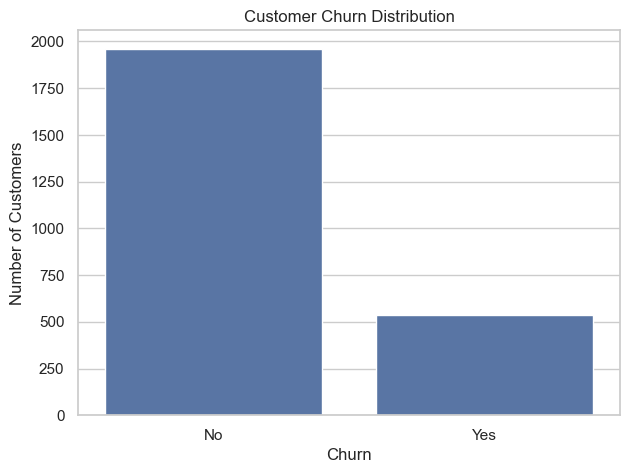

In [30]:
churn_counts = df["churn"].value_counts()

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

### 9.2 Churn by Contract Type

contract_type
Month-to-Month   31.94
Two Year         12.26
One Year          9.66
month-to-month    0.00
Name: churn, dtype: float64


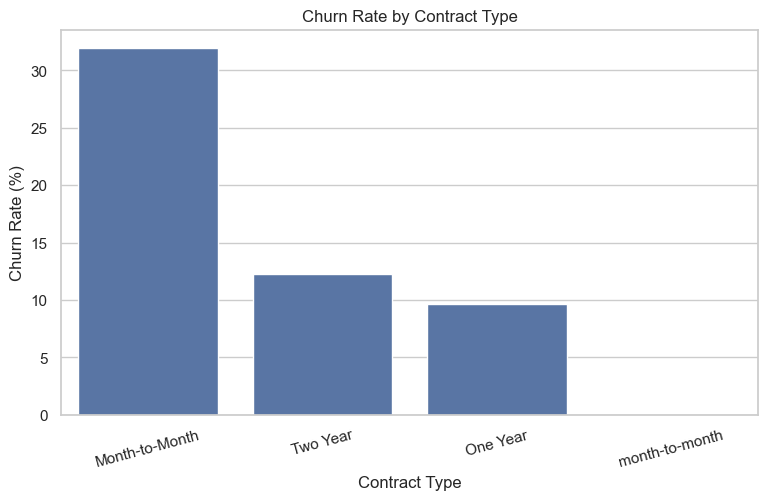

In [31]:
contract_churn = (
    df.groupby("contract_type")["churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

print(contract_churn)

plt.figure(figsize=(9, 5))
sns.barplot(x=contract_churn.index, y=contract_churn.values)
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=15)
plt.show()

### 9.3 Churn by Region

region
South   23.48
East    21.95
North   20.90
West    19.60
Name: churn, dtype: float64


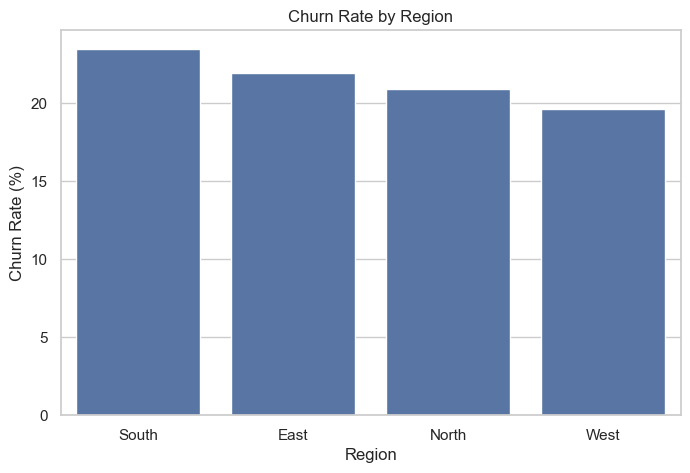

In [32]:
region_churn = (
    df.groupby("region")["churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

print(region_churn)

plt.figure(figsize=(8, 5))
sns.barplot(x=region_churn.index, y=region_churn.values)
plt.title("Churn Rate by Region")
plt.xlabel("Region")
plt.ylabel("Churn Rate (%)")
plt.show()

### 9.4 Churn by Payment Method

payment_method
Electronic Check   22.25
Bank Transfer      21.45
Mailed Check       21.24
Credit Card        20.81
Name: churn, dtype: float64


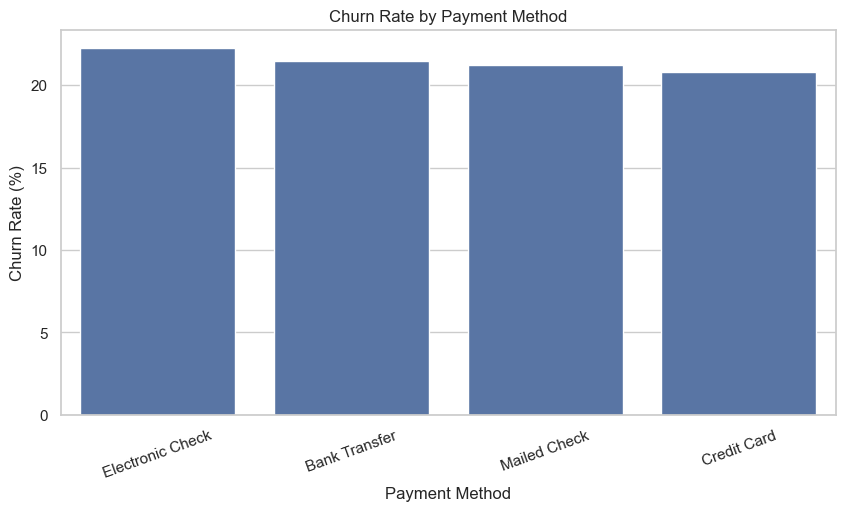

In [33]:
payment_churn = (
    df.groupby("payment_method")["churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

print(payment_churn)

plt.figure(figsize=(10, 5))
sns.barplot(x=payment_churn.index, y=payment_churn.values)
plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.show()

### 9.5 Churn by Internet Service

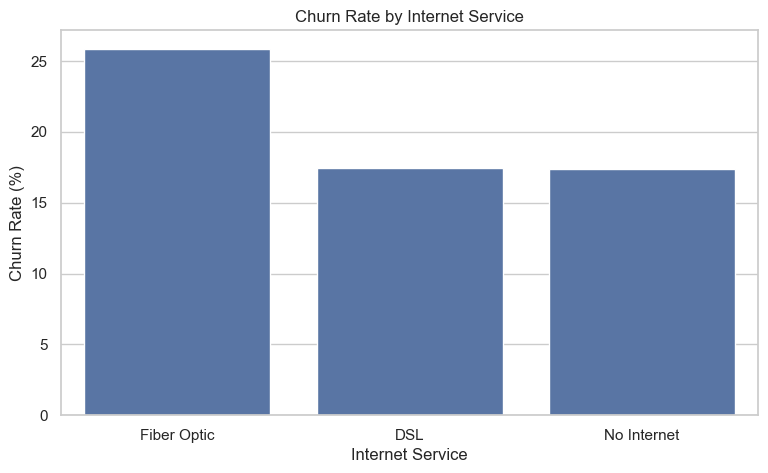

In [34]:
internet_churn = (
    df.groupby("internet_service")["churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
sns.barplot(x=internet_churn.index, y=internet_churn.values)
plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.show()

## 10. Tenure Analysis

tenure_group
0-6 Months     35.90
7-12 Months    30.80
13-24 Months   30.00
25-48 Months   20.28
49-72 Months   12.60
Name: churn, dtype: float64


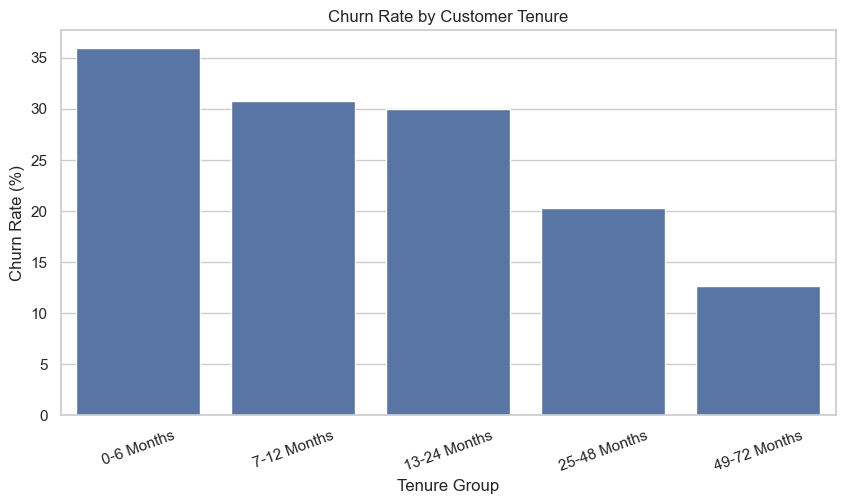

In [35]:
tenure_churn = (
    df.groupby("tenure_group", observed=True)["churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

print(tenure_churn)

plt.figure(figsize=(10, 5))
sns.barplot(x=tenure_churn.index, y=tenure_churn.values)
plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.show()

## 11. Monthly Charges vs Churn

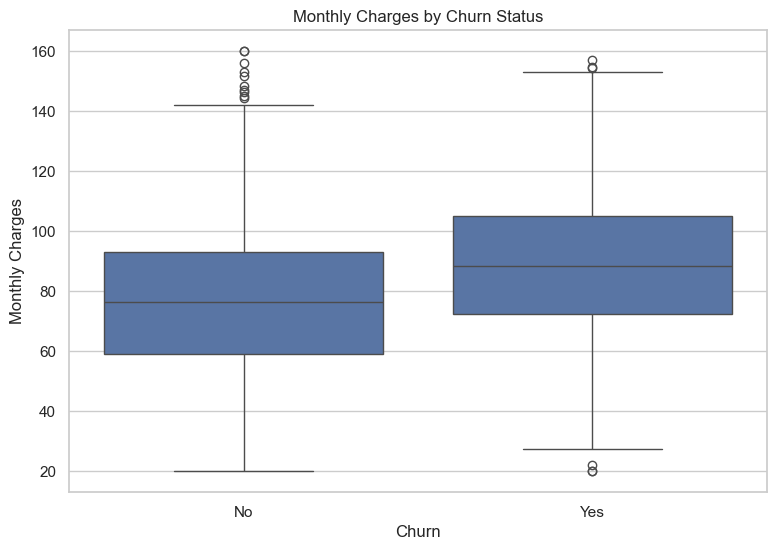

In [36]:
plt.figure(figsize=(9, 6))
sns.boxplot(data=df, x="churn", y="monthly_charges")
plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

## 12. Support Tickets vs Churn

churn
No    2.04
Yes   2.35
Name: support_tickets, dtype: float64


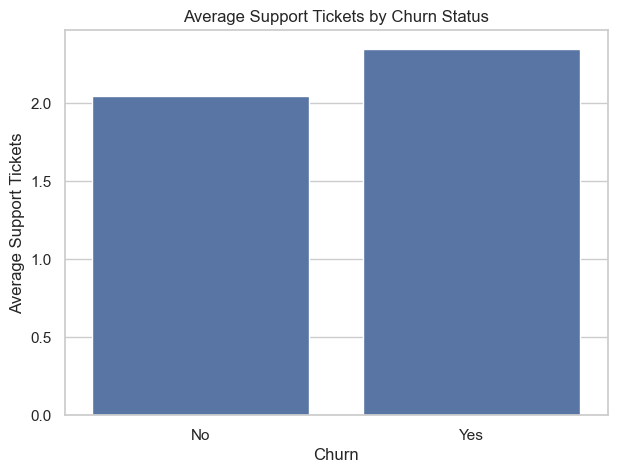

In [37]:
ticket_churn = (
    df.groupby("churn")["support_tickets"]
      .mean()
)

print(ticket_churn)

plt.figure(figsize=(7, 5))
sns.barplot(x=ticket_churn.index, y=ticket_churn.values)
plt.title("Average Support Tickets by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Average Support Tickets")
plt.show()

## 13. Late Payments vs Churn

churn
No    0.96
Yes   1.12
Name: late_payments, dtype: float64


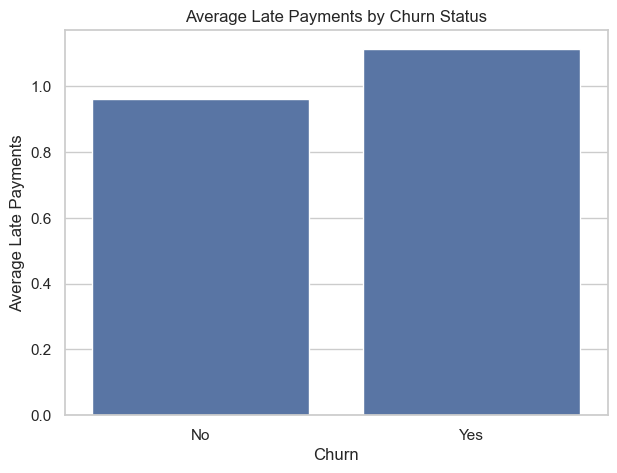

In [38]:
late_payment_churn = (
    df.groupby("churn")["late_payments"]
      .mean()
)

print(late_payment_churn)

plt.figure(figsize=(7, 5))
sns.barplot(x=late_payment_churn.index, y=late_payment_churn.values)
plt.title("Average Late Payments by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Average Late Payments")
plt.show()


## 14. Customer Value Analysis

In [39]:
value_summary = (
    df.groupby("value_segment", observed=True)
      .agg(
          customers=("customer_id", "nunique"),
          revenue=("total_charges", "sum"),
          avg_monthly_charge=("monthly_charges", "mean"),
          churn_rate=("churn", lambda x: (x == "Yes").mean() * 100)
      )
      .sort_values("revenue", ascending=False)
)

value_summary

,customers,revenue,avg_monthly_charge,churn_rate
value_segment,,,,
High Value,834,"4,352,144.90",92.67,17.03
Medium Value,833,"2,157,660.27",74.68,20.41
Low Value,833,"712,015.83",70.03,27.13


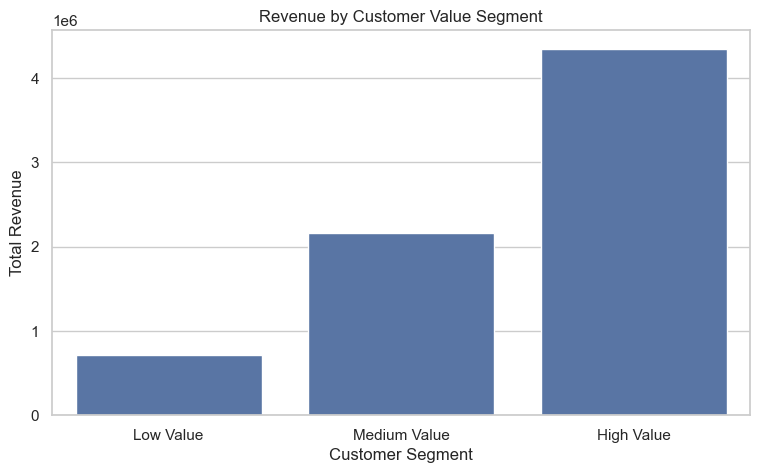

In [40]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=value_summary.reset_index(),
    x="value_segment",
    y="revenue"
)
plt.title("Revenue by Customer Value Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue")
plt.show()

## 15. High-Value Customers at Risk

In [41]:
high_value_at_risk = df[
    (df["value_segment"] == "High Value") &
    (df["churn"] == "Yes")
].copy()

high_value_at_risk = high_value_at_risk.sort_values(
    "total_charges", ascending=False
)

high_value_at_risk[
    [
        "customer_id",
        "region",
        "contract_type",
        "tenure_months",
        "monthly_charges",
        "total_charges",
        "support_tickets",
        "late_payments",
        "churn"
    ]
].head(20)

,customer_id,region,contract_type,tenure_months,monthly_charges,total_charges,support_tickets,late_payments,churn
95,10096,West,Month-to-Month,69,143.41,"9,548.26",6.00,1,Yes
834,10835,North,Month-to-Month,72,115.01,"8,942.49",4.00,3,Yes
455,10456,West,One Year,54,157.19,"8,867.42",0.00,0,Yes
931,10932,South,Month-to-Month,67,78.65,"8,809.28",1.00,2,Yes
632,10633,West,Month-to-Month,63,132.61,"8,752.37",4.00,1,Yes
622,10623,East,Month-to-Month,65,133.65,"8,318.55",1.00,2,Yes
1338,11339,South,Month-to-Month,67,117.93,"8,300.54",3.00,0,Yes
644,10645,South,Month-to-Month,70,126.77,"8,241.48",1.00,0,Yes
201,10202,North,Month-to-Month,59,129.98,"8,118.87",3.00,0,Yes
1372,11373,South,Month-to-Month,60,118.55,"7,659.15",4.00,3,Yes


## 16. Correlation Analysis

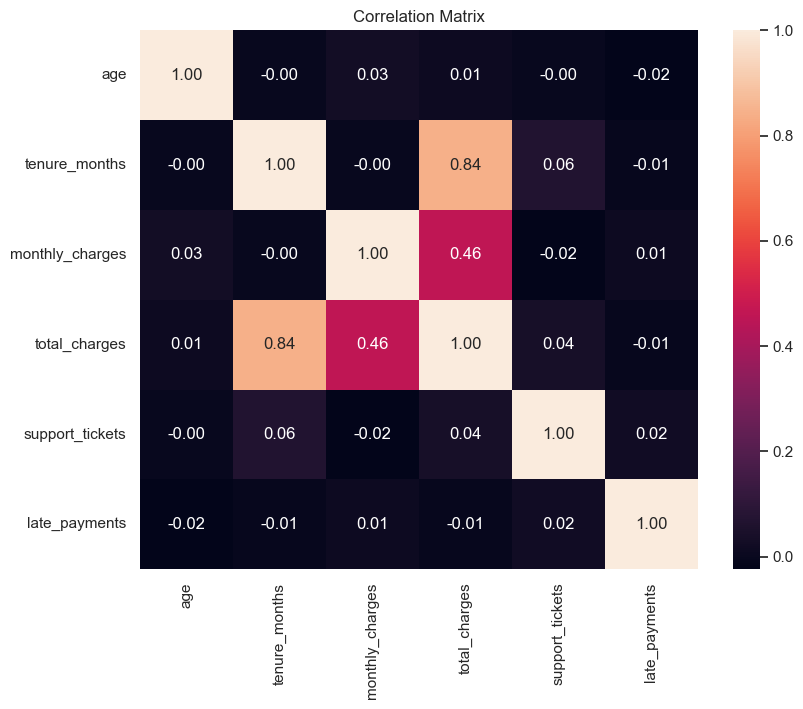

In [42]:
numeric_cols = [
    "age",
    "tenure_months",
    "monthly_charges",
    "total_charges",
    "support_tickets",
    "late_payments"
]

plt.figure(figsize=(9, 7))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

## 17. Business Case Study Summary

In [43]:
# Create a compact KPI table for management

kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Customers",
        "Churned Customers",
        "Overall Churn Rate (%)",
        "Total Revenue",
        "Average Monthly Charge"
    ],
    "Value": [
        total_customers,
        churned_customers,
        round(churn_rate, 2),
        round(total_revenue, 2),
        round(avg_monthly_charge, 2)
    ]
})

kpi_summary

,KPI,Value
0,Total Customers,"2,500.00"
1,Churned Customers,538.00
2,Overall Churn Rate (%),21.52
3,Total Revenue,"7,221,821.00"
4,Average Monthly Charge,79.13


## 18. Automated Business Findings

In [44]:
highest_contract = contract_churn.idxmax()
highest_contract_rate = contract_churn.max()

highest_region = region_churn.idxmax()
highest_region_rate = region_churn.max()

highest_payment = payment_churn.idxmax()
highest_payment_rate = payment_churn.max()

print("KEY BUSINESS FINDINGS")
print("-" * 60)
print(f"1. Overall churn rate is {churn_rate:.2f}%.")
print(
    f"2. {highest_contract} has the highest churn rate "
    f"at {highest_contract_rate:.2f}%."
)
print(
    f"3. {highest_region} has the highest regional churn rate "
    f"at {highest_region_rate:.2f}%."
)
print(
    f"4. {highest_payment} customers have the highest churn rate "
    f"at {highest_payment_rate:.2f}%."
)
print(
    f"5. There are {len(high_value_at_risk):,} high-value customers "
    "who have churned."
)

KEY BUSINESS FINDINGS
------------------------------------------------------------
1. Overall churn rate is 21.52%.
2. Month-to-Month has the highest churn rate at 31.94%.
3. South has the highest regional churn rate at 23.48%.
4. Electronic Check customers have the highest churn rate at 22.25%.
5. There are 142 high-value customers who have churned.


## 19. Business Recommendations

Based on the analysis, management should consider:

### Recommendation 1 — Retention for Month-to-Month Customers
Month-to-month customers should receive targeted retention offers, loyalty benefits and incentives to move to longer contracts.

### Recommendation 2 — Focus on High-Value Customers
High-value churned customers represent an important revenue risk. Create a priority retention program for customers with high historical revenue.

### Recommendation 3 — Payment Experience
If a payment method shows unusually high churn, investigate payment failures, customer experience and billing friction.

### Recommendation 4 — Proactive Support
Customers with frequent support tickets should be monitored because repeated service problems can be an early churn signal.

### Recommendation 5 — Early-Tenure Retention
New customers should receive onboarding support during their first 6–12 months because early churn can have a large impact on customer lifetime value.

## Skills Demonstrated

**Python:** Pandas, NumPy

**Data Cleaning:** Missing values, duplicates, data types, text standardization, validation

**EDA:** GroupBy, aggregation, segmentation, descriptive statistics

**Visualization:** Matplotlib, Seaborn

**Business Analysis:** Churn rate, revenue, customer value, risk identification

**Interview Skills:** Problem solving, KPI analysis, insight generation and business recommendations